# Lab Assignment 01

## Predicting Diabetes with Multilayer Perceptron

**Course:** CSE 4192 – Machine Learning Projects with Python

**Dataset:** Pima Indians Diabetes Dataset

In [1]:
from google.colab import files
uploaded = files.upload()


Saving diabetes.csv to diabetes.csv


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

In [3]:
df = pd.read_csv("diabetes.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
print("First 5 Records")
display(df.head())

print("Last 5 Records")
display(df.tail())

First 5 Records


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


Last 5 Records


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76.0,48,180.0,32.9,0.171,63,0
764,2,122,70.0,27,102.5,36.8,0.340,27,0
765,5,121,72.0,23,112.0,26.2,0.245,30,0
766,1,126,60.0,32,169.5,30.1,0.349,47,1
767,1,93,70.0,31,102.5,30.4,0.315,23,0


In [5]:
rows, cols = df.shape

print(f"Number of Rows    : {rows}")
print(f"Number of Columns : {cols}")

Number of Rows    : 768
Number of Columns : 9


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


In [7]:
dtype_table = pd.DataFrame({
    "Feature": df.columns,
    "Data Type": df.dtypes.values
})

dtype_table

,Feature,Data Type
0,Pregnancies,int64
1,Glucose,int64
2,BloodPressure,float64
3,SkinThickness,int64
4,Insulin,float64
5,BMI,float64
6,DiabetesPedigreeFunction,float64
7,Age,int64
8,Outcome,int64


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,121.677083,30.464161,44.000,99.75000,117.0000,140.25000,199.00
BloodPressure,768.0,72.389323,12.106039,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,768.0,29.089844,8.890820,7.000,25.00000,28.0000,32.00000,99.00
Insulin,768.0,141.753906,89.100847,14.000,102.50000,102.5000,169.50000,846.00
BMI,768.0,32.434635,6.880498,18.200,27.50000,32.0500,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [9]:
print("Target Variable :", "Outcome")
print("\nMeaning")
print("0 = Non-Diabetic")
print("1 = Diabetic")

Target Variable : Outcome

Meaning
0 = Non-Diabetic
1 = Diabetic


In [10]:
class_count = df["Outcome"].value_counts()

display(class_count)

print("\nPercentage Distribution")
display((class_count/len(df)*100).round(2))

,count
Outcome,
0,500
1,268



Percentage Distribution


,count
Outcome,
0,65.1
1,34.9


In [11]:
summary = pd.DataFrame({
    "Property":[
        "Dataset Name",
        "Rows",
        "Columns",
        "Input Features",
        "Target Variable",
        "Problem Type"
    ],
    "Value":[
        "Pima Indians Diabetes",
        rows,
        cols,
        cols-1,
        "Outcome",
        "Binary Classification"
    ]
})

summary

,Property,Value
0,Dataset Name,Pima Indians Diabetes
1,Rows,768
2,Columns,9
3,Input Features,8
4,Target Variable,Outcome
5,Problem Type,Binary Classification


### Observation

- The dataset contains 768 patient records and 9 attributes.
- Eight attributes are clinical measurements, while **Outcome** is the binary target variable.
- The problem is a supervised binary classification task where 0 represents non-diabetic patients and 1 represents diabetic patients.
- All variables are numerical, making the dataset suitable for machine learning algorithms without categorical encoding.

In [12]:
print("Missing values in each column:\n")
display(df.isnull().sum())

print("\nTotal Missing Values:", df.isnull().sum().sum())

Missing values in each column:



,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0



Total Missing Values: 0


### Missing Value Analysis

- No missing values are present in the dataset.
- However, some medical attributes may contain **0**, which is physiologically implausible and will be handled during preprocessing.

/tmp/ipykernel_1335/1120909544.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="Outcome", palette="Set2")


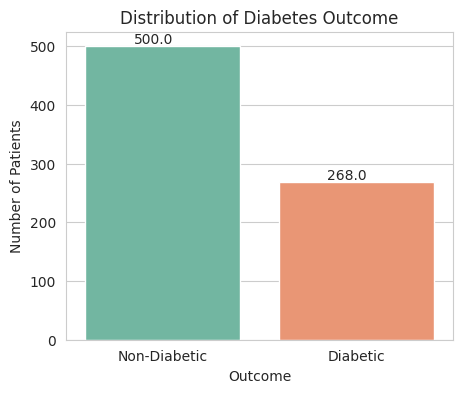

In [13]:
plt.figure(figsize=(5,4))

ax = sns.countplot(data=df, x="Outcome", palette="Set2")

plt.title("Distribution of Diabetes Outcome")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")
plt.xticks([0,1],["Non-Diabetic","Diabetic"])

for p in ax.patches:
    ax.annotate(f'{p.get_height()}',
                (p.get_x()+0.25,p.get_height()+5))

plt.show()

### Observation

The dataset contains more non-diabetic patients than diabetic patients. The class imbalance is moderate, so stratified train-test splitting will be used later.

In [14]:
percentage = (df["Outcome"].value_counts(normalize=True)*100).round(2)

percentage_df = pd.DataFrame({
    "Class":["Non-Diabetic","Diabetic"],
    "Percentage":[percentage[0], percentage[1]]
})

display(percentage_df)

,Class,Percentage
0,Non-Diabetic,65.1
1,Diabetic,34.9


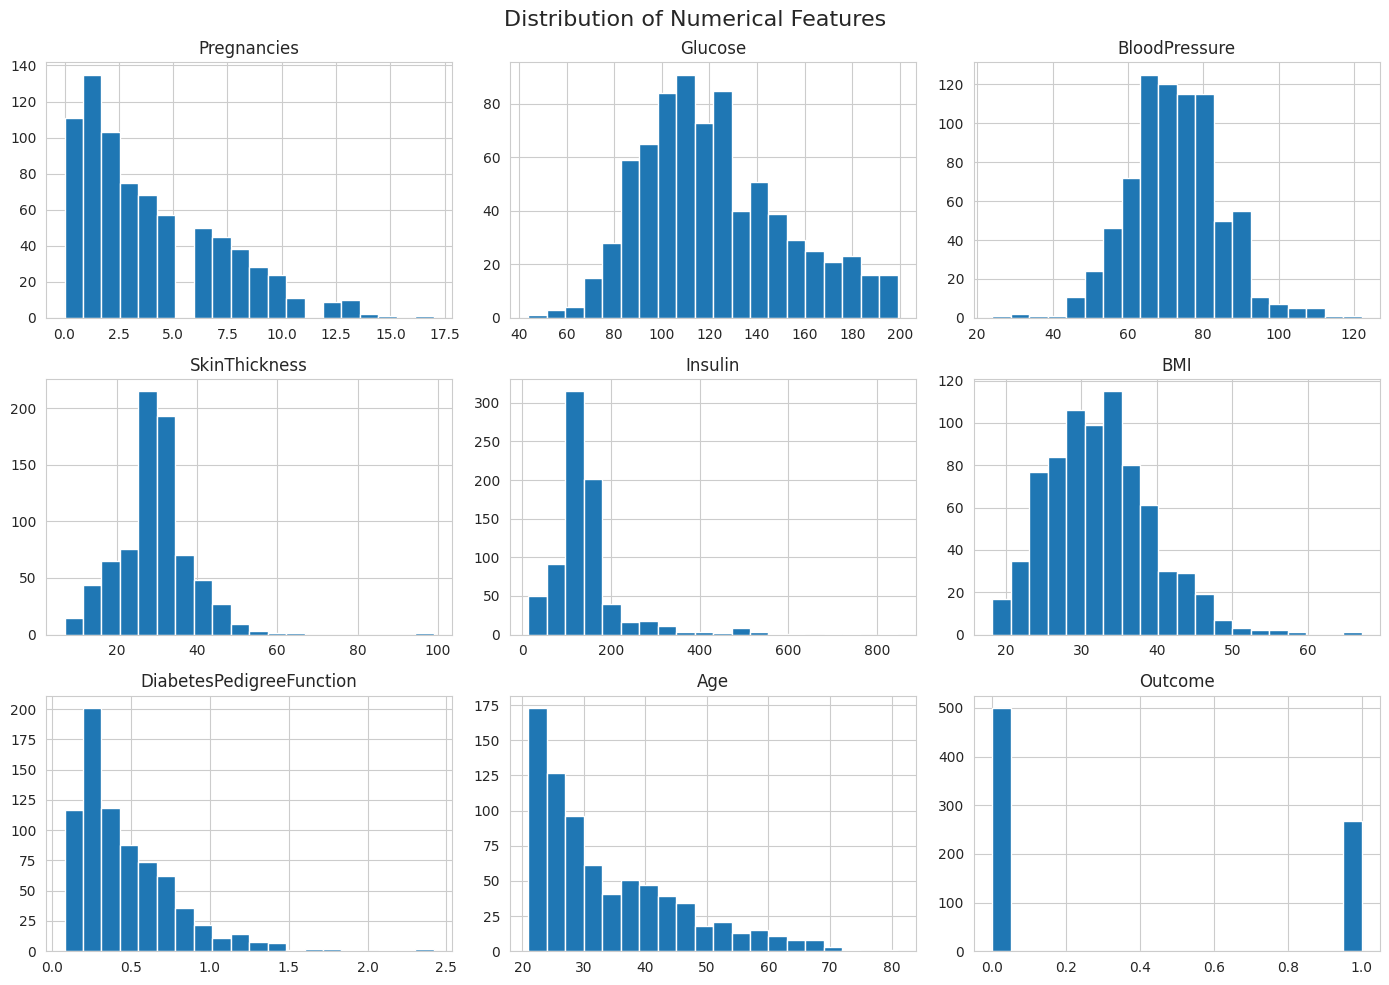

In [15]:
df.hist(figsize=(14,10), bins=20)
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

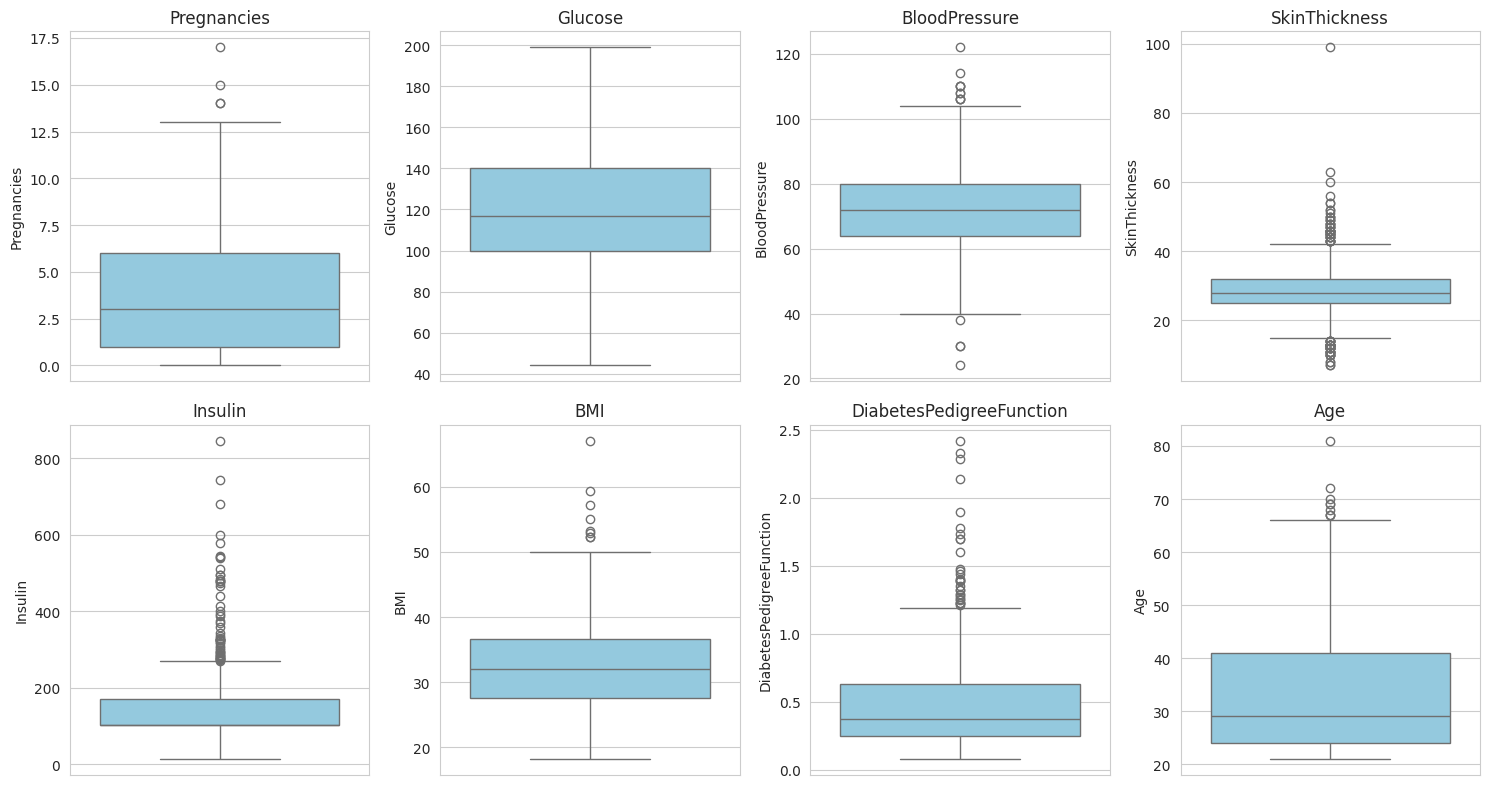

In [16]:
plt.figure(figsize=(15,8))

for i, column in enumerate(df.columns[:-1]):
    plt.subplot(2,4,i+1)
    sns.boxplot(y=df[column], color="skyblue")
    plt.title(column)

plt.tight_layout()
plt.show()

### Univariate Analysis

- Glucose and BMI show wide variation among patients.
- Insulin is highly skewed with several extreme values.
- Age is positively skewed, with most patients belonging to younger age groups.
- Boxplots indicate potential outliers in Glucose, Insulin, BMI, and SkinThickness.

In [17]:
skew_table = pd.DataFrame({
    "Feature": df.columns[:-1],
    "Skewness": df[df.columns[:-1]].skew().values
})

display(skew_table.sort_values("Skewness", ascending=False))

,Feature,Skewness
4,Insulin,3.028046
6,DiabetesPedigreeFunction,1.919911
7,Age,1.129597
0,Pregnancies,0.901674
3,SkinThickness,0.817477
5,BMI,0.606416
1,Glucose,0.532324
2,BloodPressure,0.140830


/tmp/ipykernel_1335/1211552571.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Outcome", y="Glucose", palette="Set2")


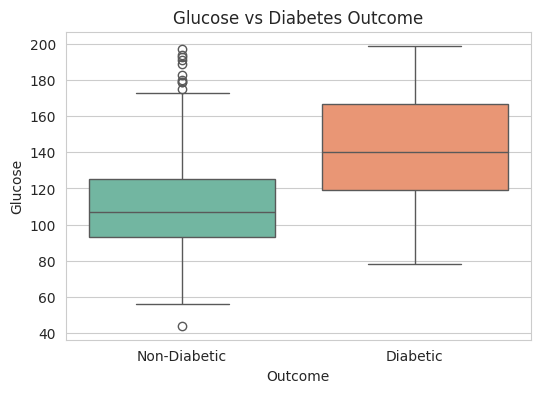

In [18]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Outcome", y="Glucose", palette="Set2")

plt.xticks([0,1],["Non-Diabetic","Diabetic"])
plt.title("Glucose vs Diabetes Outcome")
plt.show()

/tmp/ipykernel_1335/3019432218.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Outcome", y="BMI", palette="Pastel1")


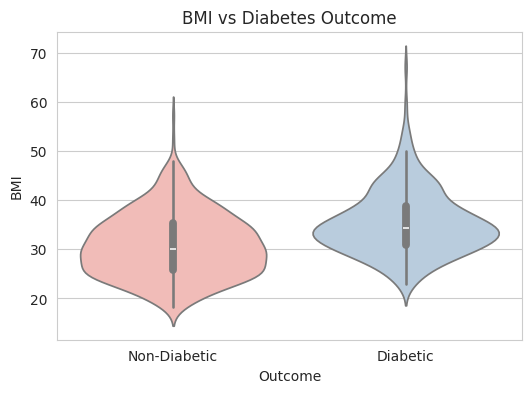

In [19]:
plt.figure(figsize=(6,4))
sns.violinplot(data=df, x="Outcome", y="BMI", palette="Pastel1")

plt.xticks([0,1],["Non-Diabetic","Diabetic"])
plt.title("BMI vs Diabetes Outcome")
plt.show()

/tmp/ipykernel_1335/1732902168.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Outcome", y="Age", palette="coolwarm")


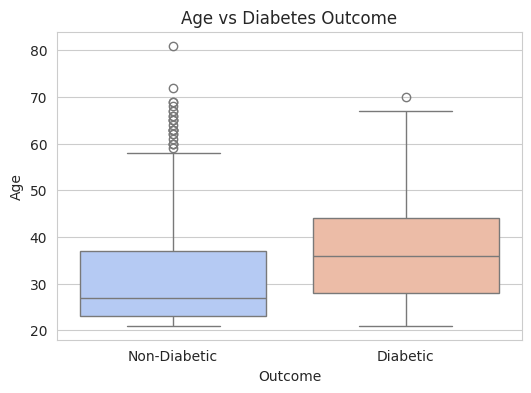

In [20]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Outcome", y="Age", palette="coolwarm")

plt.xticks([0,1],["Non-Diabetic","Diabetic"])
plt.title("Age vs Diabetes Outcome")
plt.show()

/tmp/ipykernel_1335/3184555529.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Outcome", y="Pregnancies", palette="Set3")


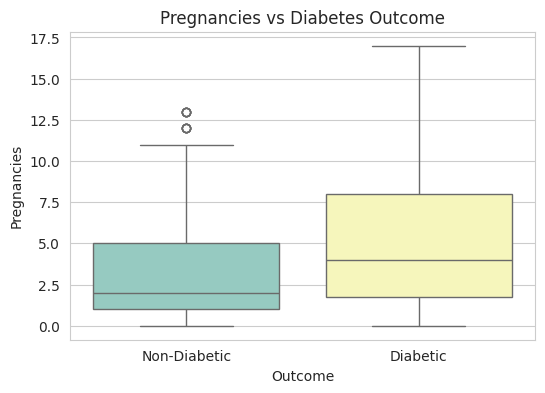

In [21]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Outcome", y="Pregnancies", palette="Set3")

plt.xticks([0,1],["Non-Diabetic","Diabetic"])
plt.title("Pregnancies vs Diabetes Outcome")
plt.show()

### Bivariate Analysis

Patients with diabetes generally exhibit:

- Higher glucose levels
- Higher BMI
- Greater age
- More pregnancies on average

Glucose appears to be one of the strongest discriminating features.

In [22]:
corr = df.corr()

display(corr.round(2))

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.00,0.13,0.21,0.09,0.06,0.02,-0.03,0.54,0.22
Glucose,0.13,1.00,0.23,0.23,0.49,0.24,0.14,0.27,0.50
BloodPressure,0.21,0.23,1.00,0.20,0.07,0.29,-0.00,0.33,0.17
SkinThickness,0.09,0.23,0.20,1.00,0.20,0.57,0.11,0.13,0.30
Insulin,0.06,0.49,0.07,0.20,1.00,0.24,0.15,0.12,0.38
BMI,0.02,0.24,0.29,0.57,0.24,1.00,0.15,0.03,0.32
DiabetesPedigreeFunction,-0.03,0.14,-0.00,0.11,0.15,0.15,1.00,0.03,0.17
Age,0.54,0.27,0.33,0.13,0.12,0.03,0.03,1.00,0.24
Outcome,0.22,0.50,0.17,0.30,0.38,0.32,0.17,0.24,1.00


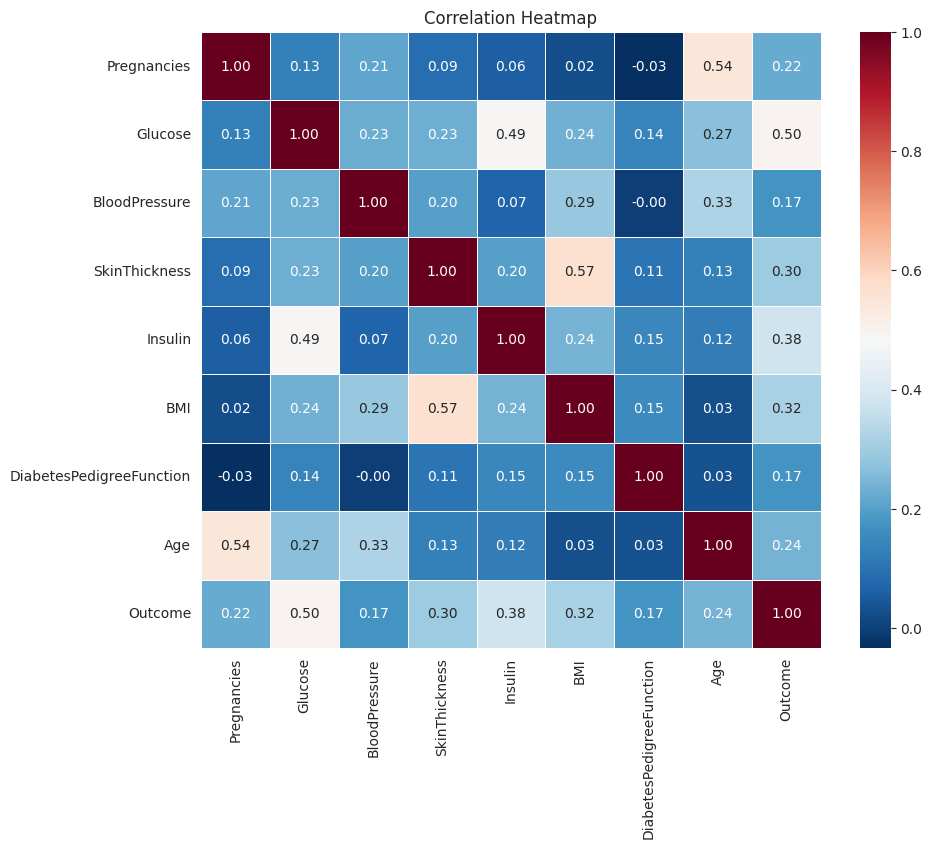

In [23]:
plt.figure(figsize=(10,8))

sns.heatmap(corr,
            annot=True,
            cmap="RdBu_r",
            fmt=".2f",
            linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

### Correlation Analysis

- Glucose has the strongest positive correlation with Outcome.
- BMI and Age also show meaningful positive relationships.
- No pair of independent variables exhibits extremely high correlation, indicating limited multicollinearity.

In [24]:
outlier_summary = []

for col in df.columns[:-1]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]

    outlier_summary.append([col, outliers])

outlier_df = pd.DataFrame(outlier_summary,
                          columns=["Feature","No. of Outliers"])

display(outlier_df)

,Feature,No. of Outliers
0,Pregnancies,4
1,Glucose,0
2,BloodPressure,14
3,SkinThickness,87
4,Insulin,51
5,BMI,8
6,DiabetesPedigreeFunction,29
7,Age,9


In [25]:
from scipy.stats import zscore

z_scores = np.abs(zscore(df[df.columns[:-1]]))

outlier_count = (z_scores > 3).sum(axis=0)

z_df = pd.DataFrame({
    "Feature": df.columns[:-1],
    "Z-score Outliers": outlier_count
})

display(z_df)

,Feature,Z-score Outliers
0,Pregnancies,4
1,Glucose,0
2,BloodPressure,8
3,SkinThickness,4
4,Insulin,19
5,BMI,5
6,DiabetesPedigreeFunction,11
7,Age,5


### Outlier Analysis

Outliers were identified using both the IQR and Z-score methods.

- Insulin contains the highest number of extreme observations.
- Glucose and BMI also contain several outliers.
- These values are **not removed immediately** because they may represent genuine diabetic patients rather than measurement errors.

In [26]:
# Create a copy for preprocessing
df_clean = df.copy()

print("Working dataframe created!")

Working dataframe created!


In [27]:
duplicates = df_clean.duplicated().sum()

print("Duplicate Records:", duplicates)

Duplicate Records: 0


### Duplicate Analysis

No duplicate records were found in the dataset. Therefore, no rows were removed.

In [28]:
invalid_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

invalid_summary = pd.DataFrame({
    "Feature": invalid_columns,
    "Invalid Zeros": [(df_clean[col] == 0).sum() for col in invalid_columns]
})

display(invalid_summary)

,Feature,Invalid Zeros
0,Glucose,0
1,BloodPressure,0
2,SkinThickness,0
3,Insulin,0
4,BMI,0


In [31]:
for col in invalid_columns:
    median_value = df_clean[df_clean[col] != 0][col].median()
    df_clean[col] = df_clean[col].replace(0, median_value)

print("Invalid values replaced successfully.")

Invalid values replaced successfully.


In [32]:
verification = pd.DataFrame({
    "Feature": invalid_columns,
    "Remaining Zeros": [(df_clean[col] == 0).sum() for col in invalid_columns]
})

display(verification)

,Feature,Remaining Zeros
0,Glucose,0
1,BloodPressure,0
2,SkinThickness,0
3,Insulin,0
4,BMI,0


### Missing/Invalid Value Handling

The dataset contained several physiologically impossible zero values in Glucose, BloodPressure, SkinThickness, Insulin, and BMI.

Instead of removing observations, zeros were replaced using the **median** of the corresponding feature because median imputation is robust to outliers and preserves the overall distribution.

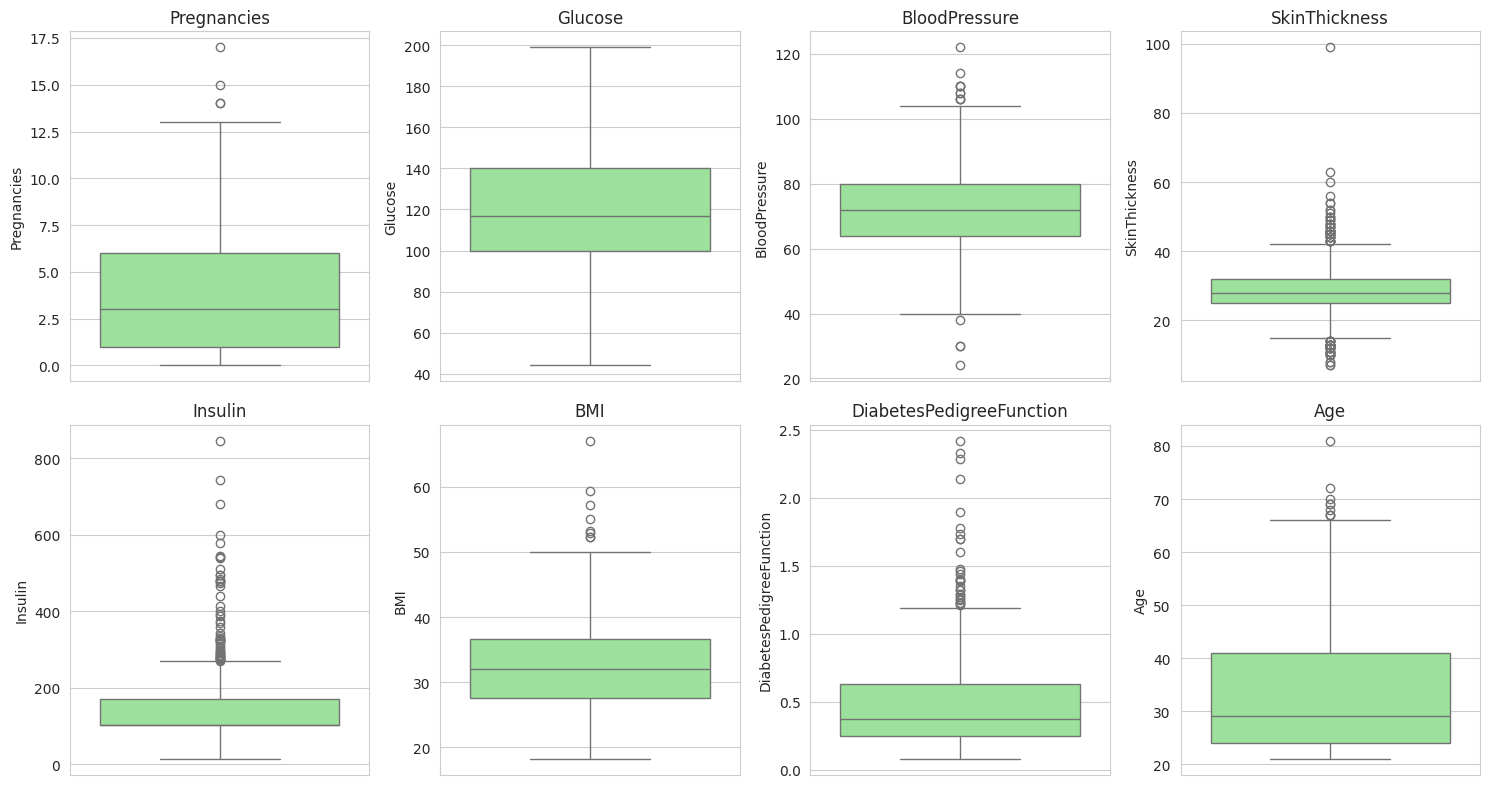

In [33]:
plt.figure(figsize=(15,8))

for i, col in enumerate(df_clean.columns[:-1]):
    plt.subplot(2,4,i+1)
    sns.boxplot(y=df_clean[col], color="lightgreen")
    plt.title(col)

plt.tight_layout()
plt.show()

### Outlier Handling

Outliers were retained because they may correspond to genuine diabetic patients rather than erroneous measurements. Removing them could reduce the model's ability to recognize high-risk cases.

In [34]:
df_clean["AgeGroup"] = pd.cut(
    df_clean["Age"],
    bins=[20,30,40,50,60,100],
    labels=[0,1,2,3,4],
    include_lowest=True
)

df_clean["AgeGroup"] = df_clean["AgeGroup"].astype(int)

In [35]:
df_clean["BMICategory"] = pd.cut(
    df_clean["BMI"],
    bins=[0,18.5,25,30,100],
    labels=[0,1,2,3],
    include_lowest=True
)

df_clean["BMICategory"] = df_clean["BMICategory"].astype(int)

In [36]:
df_clean[["Age","AgeGroup","BMI","BMICategory"]].head(10)

,Age,AgeGroup,BMI,BMICategory
0,50,2,33.6,3
1,31,1,26.6,2
2,32,1,23.3,1
3,21,0,28.1,2
4,33,1,43.1,3
5,30,0,25.6,2
6,26,0,31.0,3
7,29,0,35.3,3
8,53,3,30.5,3
9,54,3,34.3,3


### Feature Engineering

Two additional features were created:

- **AgeGroup:** Categorizes patients into age intervals.
- **BMICategory:** Converts BMI into clinically meaningful weight categories.

These engineered features may help the neural network learn non-linear health patterns more effectively.

In [37]:
X = df_clean.drop("Outcome", axis=1)
y = df_clean["Outcome"]

print("Feature Shape :", X.shape)
print("Target Shape  :", y.shape)

Feature Shape : (768, 10)
Target Shape  : (768,)


In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

Training Samples : 614
Testing Samples  : 154


In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


In [40]:
before_after = pd.DataFrame({
    "Feature": X.columns,
    "Original Mean": X_train.mean().round(2).values,
    "Scaled Mean": X_train_scaled.mean(axis=0).round(2),
    "Scaled Std": X_train_scaled.std(axis=0).round(2)
})

display(before_after)

,Feature,Original Mean,Scaled Mean,Scaled Std
0,Pregnancies,3.82,-0.0,1.0
1,Glucose,121.71,-0.0,1.0
2,BloodPressure,72.15,0.0,1.0
3,SkinThickness,29.02,-0.0,1.0
4,Insulin,138.54,0.0,1.0
5,BMI,32.43,-0.0,1.0
6,DiabetesPedigreeFunction,0.48,-0.0,1.0
7,Age,33.37,-0.0,1.0
8,AgeGroup,0.86,-0.0,1.0
9,BMICategory,2.47,-0.0,1.0


### Feature Scaling

Standardization was applied using **StandardScaler**.

The scaler was fitted **only on the training set** and then applied to the test set to prevent data leakage. Scaling ensures that features with different units contribute equally during model training, particularly for distance-based algorithms and neural networks.

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

import time

In [42]:
results = []

def evaluate_model(name, model, X_train, X_test, y_train, y_test):

    start = time.time()
    model.fit(X_train, y_train)
    end = time.time()

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": pre,
        "Recall": rec,
        "F1": f1,
        "ROC_AUC": auc,
        "Train_Time": end-start
    })

    print("="*45)
    print(name)
    print("="*45)
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {pre:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"ROC AUC   : {auc:.4f}")

    # Confusion Matrix
    fig, ax = plt.subplots(figsize=(4,4))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues", ax=ax)
    plt.title(f"{name} Confusion Matrix")
    plt.show()

    # ROC Curve
    RocCurveDisplay.from_estimator(model, X_test, y_test)
    plt.title(f"{name} ROC Curve")
    plt.show()

    # Precision Recall
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test)
    plt.title(f"{name} Precision-Recall Curve")
    plt.show()

    return model

Logistic Regression
Accuracy  : 0.7143
Precision : 0.5962
Recall    : 0.5741
F1 Score  : 0.5849
ROC AUC   : 0.8317


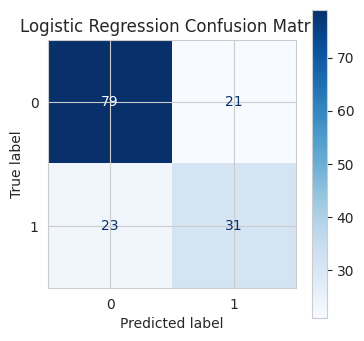

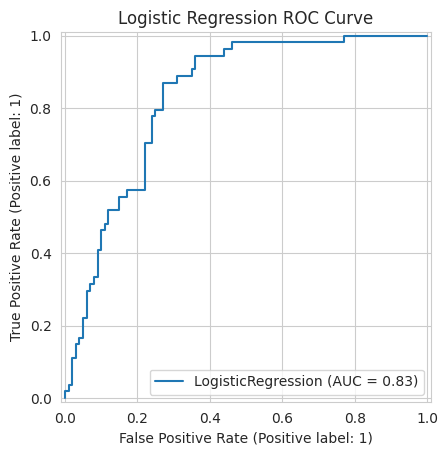

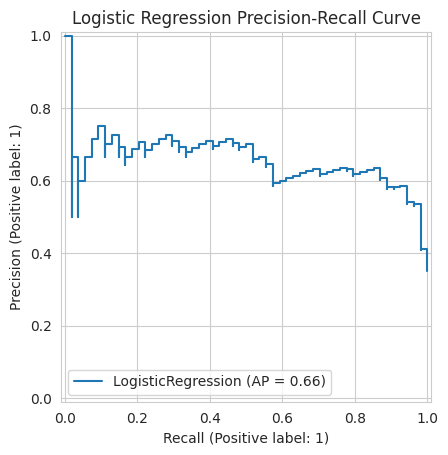

In [43]:
lr_model = LogisticRegression(random_state=42)

lr_model = evaluate_model(
    "Logistic Regression",
    lr_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

### Logistic Regression

Logistic Regression provides a strong baseline for binary classification. Since the features were standardized, the model performs efficiently and offers good interpretability.

K-Nearest Neighbors
Accuracy  : 0.8117
Precision : 0.7451
Recall    : 0.7037
F1 Score  : 0.7238
ROC AUC   : 0.8557


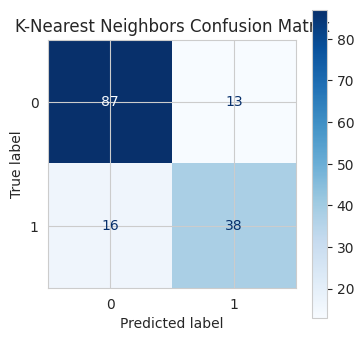

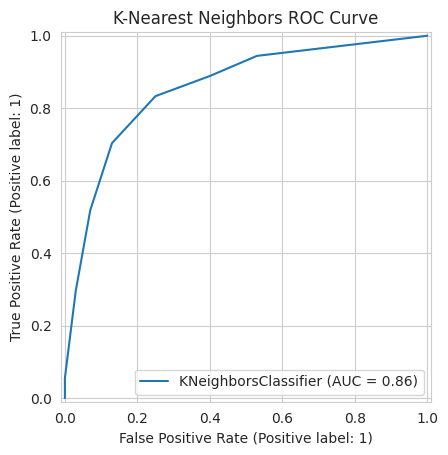

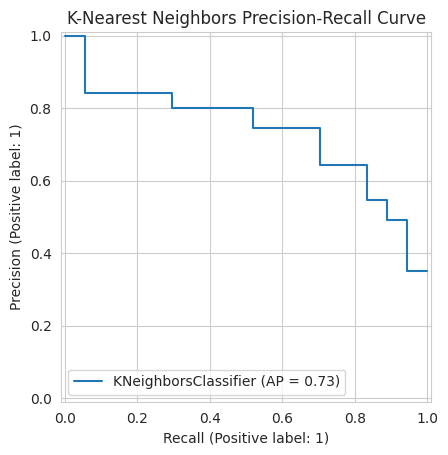

In [44]:
knn_model = KNeighborsClassifier(n_neighbors=7)

knn_model = evaluate_model(
    "K-Nearest Neighbors",
    knn_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

### K-Nearest Neighbors

KNN is a distance-based classifier; therefore feature scaling is essential. The model predicts diabetes by considering the nearest patients in the feature space.

Support Vector Machine
Accuracy  : 0.8377
Precision : 0.7636
Recall    : 0.7778
F1 Score  : 0.7706
ROC AUC   : 0.8972


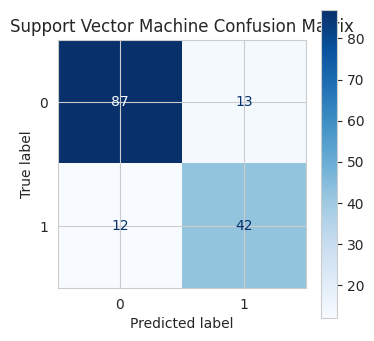

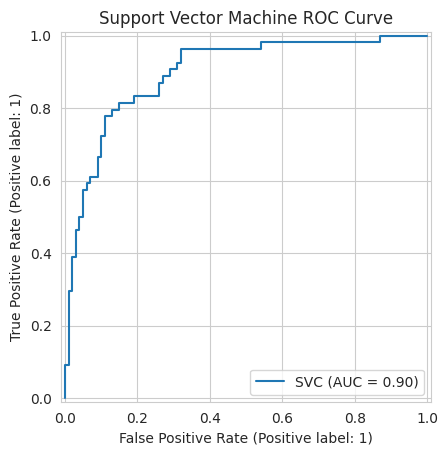

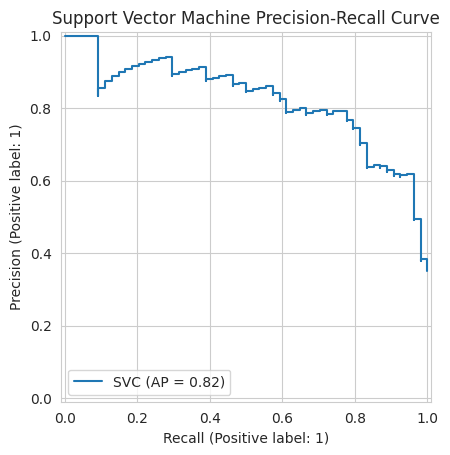

In [45]:
svm_model = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

svm_model = evaluate_model(
    "Support Vector Machine",
    svm_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

### Support Vector Machine

The RBF kernel enables the SVM to capture nonlinear relationships between clinical features and diabetes outcome.

Random Forest
Accuracy  : 0.8636
Precision : 0.8235
Recall    : 0.7778
F1 Score  : 0.8000
ROC AUC   : 0.9469


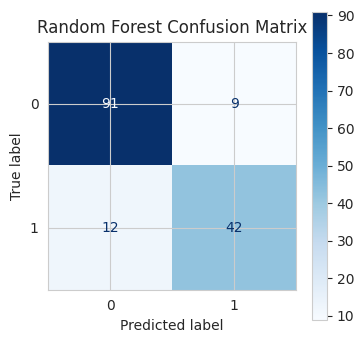

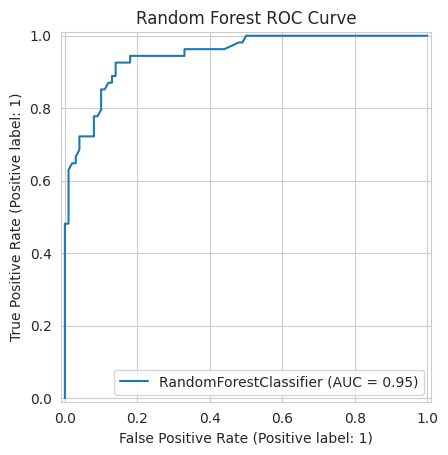

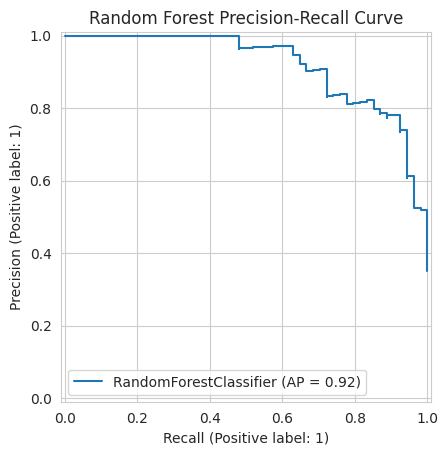

In [46]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model = evaluate_model(
    "Random Forest",
    rf_model,
    X_train,
    X_test,
    y_train,
    y_test
)

### Random Forest

Random Forest combines multiple decision trees and is generally robust to outliers and nonlinear relationships. It also provides feature importance for interpretation.

In [47]:
baseline_results = pd.DataFrame(results)

baseline_results = baseline_results.round(4)

baseline_results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Train_Time
0,Logistic Regression,0.7143,0.5962,0.5741,0.5849,0.8317,0.0171
1,K-Nearest Neighbors,0.8117,0.7451,0.7037,0.7238,0.8557,0.0034
2,Support Vector Machine,0.8377,0.7636,0.7778,0.7706,0.8972,0.0551
3,Random Forest,0.8636,0.8235,0.7778,0.8000,0.9469,0.6705


In [48]:
best = baseline_results.sort_values(
    "ROC_AUC",
    ascending=False
)

best

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Train_Time
3,Random Forest,0.8636,0.8235,0.7778,0.8000,0.9469,0.6705
2,Support Vector Machine,0.8377,0.7636,0.7778,0.7706,0.8972,0.0551
1,K-Nearest Neighbors,0.8117,0.7451,0.7037,0.7238,0.8557,0.0034
0,Logistic Regression,0.7143,0.5962,0.5741,0.5849,0.8317,0.0171


### Baseline Model Comparison

The four conventional machine learning models were compared using Accuracy, Precision, Recall, F1-score, and ROC-AUC. The final deployment model will **not** be selected solely based on accuracy; recall and ROC-AUC are particularly important for medical diagnosis.

In [49]:
!pip -q install tensorflow

In [50]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [51]:
tf.random.set_seed(42)

mlp = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

mlp.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

mlp.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

In [53]:
history = mlp.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.6375 - loss: 0.6580 - val_accuracy: 0.6992 - val_loss: 0.5833
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7067 - loss: 0.5659 - val_accuracy: 0.7480 - val_loss: 0.5135
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7454 - loss: 0.4988 - val_accuracy: 0.7480 - val_loss: 0.4782
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7780 - loss: 0.4726 - val_accuracy: 0.7561 - val_loss: 0.4585
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7800 - loss: 0.4526 - val_accuracy: 0.7642 - val_loss: 0.4431
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8045 - loss: 0.4362 - val_accuracy: 0.7886 - val_loss: 0.4313
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7943 - loss: 0.4371 - val_accuracy: 0.7886 - val_loss: 0.4240
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7862 - loss: 0.4293 - val_accuracy: 0.

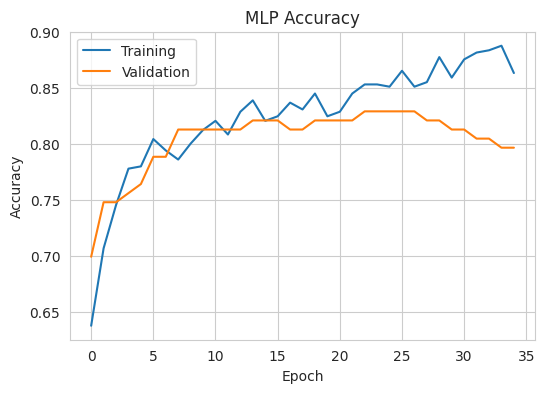

In [54]:
plt.figure(figsize=(6,4))

plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')

plt.title("MLP Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

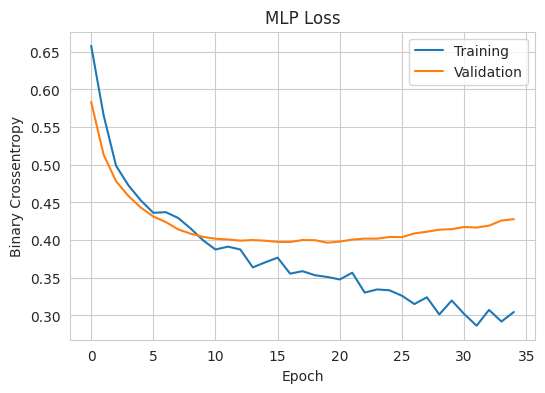

In [55]:
plt.figure(figsize=(6,4))

plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')

plt.title("MLP Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Crossentropy")
plt.legend()

plt.show()

In [56]:
y_prob = mlp.predict(X_test_scaled)
y_prob = y_prob.flatten()

y_pred = (y_prob >= 0.5).astype(int)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


In [57]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

mlp_accuracy = accuracy_score(y_test, y_pred)
mlp_precision = precision_score(y_test, y_pred)
mlp_recall = recall_score(y_test, y_pred)
mlp_f1 = f1_score(y_test, y_pred)
mlp_auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", round(mlp_accuracy,4))
print("Precision:", round(mlp_precision,4))
print("Recall   :", round(mlp_recall,4))
print("F1 Score :", round(mlp_f1,4))
print("ROC AUC  :", round(mlp_auc,4))

Accuracy : 0.7987
Precision: 0.6769
Recall   : 0.8148
F1 Score : 0.7395
ROC AUC  : 0.8743


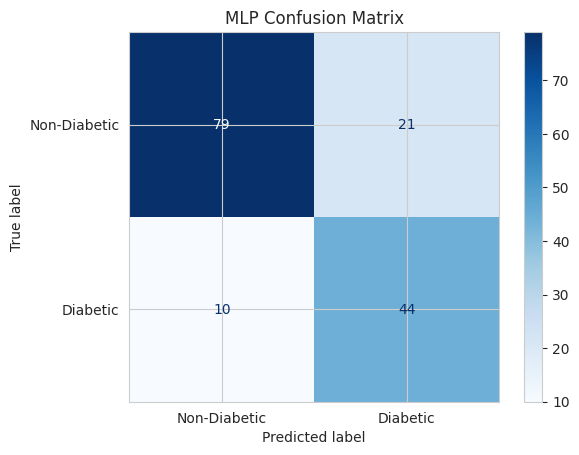

In [58]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm, display_labels=["Non-Diabetic","Diabetic"])

disp.plot(cmap="Blues")
plt.title("MLP Confusion Matrix")
plt.show()

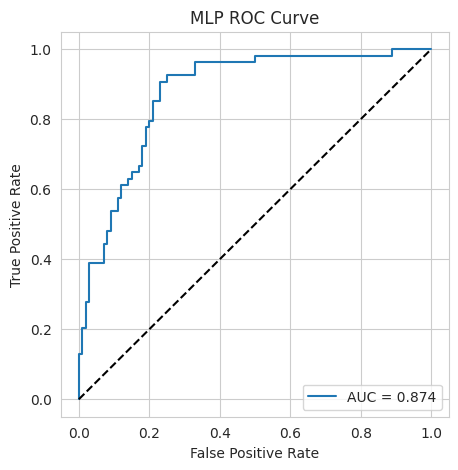

In [59]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(5,5))

plt.plot(fpr, tpr, label=f"AUC = {mlp_auc:.3f}")
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("MLP ROC Curve")
plt.legend()

plt.show()

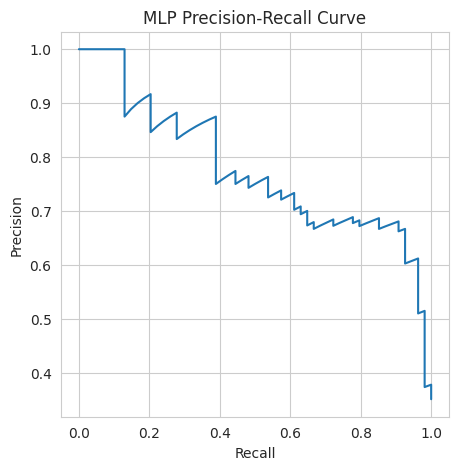

In [60]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(5,5))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("MLP Precision-Recall Curve")

plt.show()

In [61]:
results.append({
    "Model":"Multilayer Perceptron",
    "Accuracy":mlp_accuracy,
    "Precision":mlp_precision,
    "Recall":mlp_recall,
    "F1":mlp_f1,
    "ROC_AUC":mlp_auc,
    "Train_Time":0
})

comparison = pd.DataFrame(results).round(4)

comparison = comparison.sort_values("ROC_AUC", ascending=False)

comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Train_Time
3,Random Forest,0.8636,0.8235,0.7778,0.8000,0.9469,0.6705
2,Support Vector Machine,0.8377,0.7636,0.7778,0.7706,0.8972,0.0551
4,Multilayer Perceptron,0.7987,0.6769,0.8148,0.7395,0.8743,0.0000
1,K-Nearest Neighbors,0.8117,0.7451,0.7037,0.7238,0.8557,0.0034
0,Logistic Regression,0.7143,0.5962,0.5741,0.5849,0.8317,0.0171


In [62]:
from itertools import product
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

learning_rates = [0.001, 0.0005]
neurons = [32, 64]
dropouts = [0.2, 0.3]

tuning_results = []

for lr, n, d in product(learning_rates, neurons, dropouts):

    tf.keras.backend.clear_session()

    model = Sequential([
        Dense(n, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        Dropout(d),
        Dense(n//2, activation='relu'),
        Dropout(d),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train_scaled,
        y_train,
        validation_split=0.2,
        epochs=40,
        batch_size=32,
        verbose=0
    )

    best_val = max(history.history["val_accuracy"])

    tuning_results.append({
        "Learning Rate": lr,
        "Neurons": n,
        "Dropout": d,
        "Best Val Accuracy": best_val
    })

tuning_df = pd.DataFrame(tuning_results)
tuning_df.sort_values("Best Val Accuracy", ascending=False)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


,Learning Rate,Neurons,Dropout,Best Val Accuracy
3,0.0010,64,0.3,0.837398
7,0.0005,64,0.3,0.829268
6,0.0005,64,0.2,0.821138
0,0.0010,32,0.2,0.821138
2,0.0010,64,0.2,0.813008
1,0.0010,32,0.3,0.813008
5,0.0005,32,0.3,0.813008
4,0.0005,32,0.2,0.813008


In [63]:
best_params = tuning_df.sort_values(
    "Best Val Accuracy",
    ascending=False
).iloc[0]

best_params

,3
Learning Rate,0.001000
Neurons,64.000000
Dropout,0.300000
Best Val Accuracy,0.837398


In [64]:
best_lr = float(best_params["Learning Rate"])
best_neurons = int(best_params["Neurons"])
best_dropout = float(best_params["Dropout"])

final_mlp = Sequential([
    Dense(best_neurons, activation='relu',
          input_shape=(X_train_scaled.shape[1],)),
    Dropout(best_dropout),

    Dense(best_neurons//2, activation='relu'),
    Dropout(best_dropout),

    Dense(1, activation='sigmoid')
])

final_mlp.compile(
    optimizer=tf.keras.optimizers.Adam(best_lr),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_final = final_mlp.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.6375 - loss: 0.6563 - val_accuracy: 0.6829 - val_loss: 0.6015
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7230 - loss: 0.5773 - val_accuracy: 0.7317 - val_loss: 0.5376
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7230 - loss: 0.5354 - val_accuracy: 0.7642 - val_loss: 0.4939
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7536 - loss: 0.5138 - val_accuracy: 0.7642 - val_loss: 0.4696
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7760 - loss: 0.4823 - val_accuracy: 0.7724 - val_loss: 0.4522
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7984 - loss: 0.4434 - val_accuracy: 0.7967 - val_loss: 0.4384
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8004 - loss: 0.4507 - val_accuracy: 0.7886 - val_loss: 0.4283
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8086 - loss: 0.4331 - val_accuracy: 0.7967 - val_loss:

In [65]:
y_prob_final = final_mlp.predict(X_test_scaled).flatten()
y_pred_final = (y_prob_final >= 0.5).astype(int)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_final))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
              precision    recall  f1-score   support

           0       0.87      0.82      0.85       100
           1       0.70      0.78      0.74        54

    accuracy                           0.81       154
   macro avg       0.79      0.80      0.79       154
weighted avg       0.81      0.81      0.81       154



In [66]:
import joblib

final_mlp.save("diabetes_mlp.keras")
joblib.dump(scaler, "diabetes_scaler.pkl")

print("Files saved successfully!")

Files saved successfully!


In [67]:
import numpy as np

def predict_diabetes(
    pregnancies,
    glucose,
    blood_pressure,
    skin_thickness,
    insulin,
    bmi,
    dpf,
    age
):
    # Feature Engineering
    if age <= 30:
        age_group = 0
    elif age <= 40:
        age_group = 1
    elif age <= 50:
        age_group = 2
    elif age <= 60:
        age_group = 3
    else:
        age_group = 4

    if bmi < 18.5:
        bmi_cat = 0
    elif bmi < 25:
        bmi_cat = 1
    elif bmi < 30:
        bmi_cat = 2
    else:
        bmi_cat = 3

    sample = np.array([[pregnancies, glucose, blood_pressure,
                        skin_thickness, insulin,
                        bmi, dpf, age,
                        age_group, bmi_cat]])

    sample_scaled = scaler.transform(sample)

    probability = final_mlp.predict(sample_scaled, verbose=0)[0][0]

    prediction = "Diabetic" if probability >= 0.5 else "Non-Diabetic"

    print("="*40)
    print("DIABETES PREDICTION SYSTEM")
    print("="*40)
    print("Prediction :", prediction)
    print(f"Probability: {probability*100:.2f}%")

In [68]:
predict_diabetes(
    pregnancies=1,
    glucose=92,
    blood_pressure=72,
    skin_thickness=20,
    insulin=85,
    bmi=22.5,
    dpf=0.25,
    age=24
)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


DIABETES PREDICTION SYSTEM
Prediction : Non-Diabetic
Probability: 0.22%


In [69]:
predict_diabetes(
    pregnancies=6,
    glucose=178,
    blood_pressure=88,
    skin_thickness=35,
    insulin=190,
    bmi=36.4,
    dpf=1.12,
    age=51
)

DIABETES PREDICTION SYSTEM
Prediction : Diabetic
Probability: 90.54%


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [70]:
predict_diabetes(
    pregnancies=3,
    glucose=126,
    blood_pressure=78,
    skin_thickness=28,
    insulin=120,
    bmi=29.8,
    dpf=0.58,
    age=39
)

DIABETES PREDICTION SYSTEM
Prediction : Non-Diabetic
Probability: 25.79%


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [71]:
comparison = comparison.sort_values("ROC_AUC", ascending=False).reset_index(drop=True)
comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Train_Time
0,Random Forest,0.8636,0.8235,0.7778,0.8000,0.9469,0.6705
1,Support Vector Machine,0.8377,0.7636,0.7778,0.7706,0.8972,0.0551
2,Multilayer Perceptron,0.7987,0.6769,0.8148,0.7395,0.8743,0.0000
3,K-Nearest Neighbors,0.8117,0.7451,0.7037,0.7238,0.8557,0.0034
4,Logistic Regression,0.7143,0.5962,0.5741,0.5849,0.8317,0.0171


In [72]:
!pip install -q gradio

In [73]:
import gradio as gr
import numpy as np
import pandas as pd
import joblib
import tensorflow as tf

# Load trained model and scaler


MODEL_PATH = "diabetes_mlp.keras"
SCALER_PATH = "diabetes_scaler.pkl"

model = tf.keras.models.load_model(MODEL_PATH)
scaler = joblib.load(SCALER_PATH)

print("Model and scaler loaded successfully!")


# Feature engineering


def age_group(age):
    if age <= 30:
        return 0
    elif age <= 40:
        return 1
    elif age <= 50:
        return 2
    elif age <= 60:
        return 3
    else:
        return 4


def bmi_category(bmi):
    if bmi < 18.5:
        return 0
    elif bmi < 25:
        return 1
    elif bmi < 30:
        return 2
    else:
        return 3


# Prediction function


def predict_diabetes(
    pregnancies,
    glucose,
    blood_pressure,
    skin_thickness,
    insulin,
    bmi,
    diabetes_pedigree,
    age
):


    # Validate input values


    if pregnancies < 0 or pregnancies > 20:
        return "Invalid Input", "Pregnancies must be between 0 and 20."

    if glucose <= 0 or glucose > 300:
        return "Invalid Input", "Glucose must be between 1 and 300."

    if blood_pressure <= 0 or blood_pressure > 200:
        return "Invalid Input", "Blood Pressure must be between 1 and 200."

    if skin_thickness < 0 or skin_thickness > 100:
        return "Invalid Input", "Skin Thickness must be between 0 and 100."

    if insulin < 0 or insulin > 900:
        return "Invalid Input", "Insulin must be between 0 and 900."

    if bmi <= 0 or bmi > 80:
        return "Invalid Input", "BMI must be between 1 and 80."

    if diabetes_pedigree < 0 or diabetes_pedigree > 3:
        return "Invalid Input", (
            "Diabetes Pedigree Function must be between 0 and 3."
        )

    if age <= 0 or age > 120:
        return "Invalid Input", "Age must be between 1 and 120."

    # Feature engineering

    age_grp = age_group(age)
    bmi_cat = bmi_category(bmi)

    # Create input DataFrame

    feature_columns = [
        "Pregnancies",
        "Glucose",
        "BloodPressure",
        "SkinThickness",
        "Insulin",
        "BMI",
        "DiabetesPedigreeFunction",
        "Age",
        "AgeGroup",
        "BMICategory"
    ]

    input_data = pd.DataFrame(
        [[
            pregnancies,
            glucose,
            blood_pressure,
            skin_thickness,
            insulin,
            bmi,
            diabetes_pedigree,
            age,
            age_grp,
            bmi_cat
        ]],
        columns=feature_columns
    )

    # Apply the SAME scaler used during training

    input_scaled = scaler.transform(input_data)


    # Make prediction

    probability = float(
        model.predict(input_scaled, verbose=0)[0][0]
    )

    # Classification threshold = 0.50

    if probability >= 0.50:
        prediction = "Diabetic"
    else:
        prediction = "Non-Diabetic"

    probability_text = f"{probability * 100:.2f}%"

    return prediction, probability_text

# Gradio Interface

demo = gr.Interface(
    fn=predict_diabetes,

    inputs=[
        gr.Number(
            label="Pregnancies",
            value=1
        ),

        gr.Number(
            label="Glucose",
            value=120
        ),

        gr.Number(
            label="Blood Pressure",
            value=70
        ),

        gr.Number(
            label="Skin Thickness",
            value=20
        ),

        gr.Number(
            label="Insulin",
            value=80
        ),

        gr.Number(
            label="BMI",
            value=25.0
        ),

        gr.Number(
            label="Diabetes Pedigree Function",
            value=0.45
        ),

        gr.Number(
            label="Age",
            value=30
        )
    ],

    outputs=[
        gr.Textbox(
            label="Prediction"
        ),

        gr.Textbox(
            label="Diabetes Probability"
        )
    ],

    title="🩺 Diabetes Prediction System",

    description=(
        "Enter the patient's clinical attributes to predict "
        "whether the patient is likely to be diabetic. "
        "The model returns the predicted class and probability."
    ),

    examples=[
        [
            1, 90, 66, 20, 80, 24.0, 0.30, 25
        ],
        [
            6, 180, 80, 35, 200, 40.0, 1.00, 55
        ],
        [
            2, 130, 70, 25, 100, 30.0, 0.50, 40
        ]
    ]
)

# Launch

demo.launch(share=True)

Model and scaler loaded successfully!
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e819604849b6a52974.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
